# LINCS Cell Painting morphology profile analysis: batch1 plate/replicate UMAP

This is the LINCS counterpart to `morphology_umap_analysis.ipynb` (which
analyzes the HepG2 bioactive-library screen across its 4 independent
production sites). Per the same scope as `lincs_morphology_expression_integration.ipynb`,
this notebook covers **only `2016_04_01_a549_48hr_batch1`** (A549, 48h, the
~1500-compound Drug Repurposing Hub library at up to 7 doses) - not the
second LINCS batch (`2017_12_05_Batch2`), which spans 3 cell lines x 3
timepoints x 3 compound libraries and isn't a like-for-like comparison.

**Why this isn't a literal site-for-site mirror of the HepG2 notebook.**
HepG2 had 4 independent sites each re-running the *identical* 7-plate
library end to end - a clean site x plate x replicate grid, so "does site
dominate the embedding" is a pure technical-batch-effect question. Batch1's
own internal structure, carried directly in `Metadata_Batch_Number` /
`Metadata_Batch_Date` and `Metadata_Plate_Map_Name`, is different: it's a
**primary screen plus confirmatory retest** design -

- `Batch_Number` 1 (2016-03-22) runs all 28 plate-map designs once each (28
  plates) - a single broad pass across the whole library.
- `Batch_Number`s 2-5 (2016-04-05 through 2016-05-30) each deepen a
  *disjoint* subset of ~7 of those 28 designs at 3-4 replicate plates - not
  a repeat of the whole library, so `Batch_Number` is confounded with *which
  compounds* rather than being an orthogonal technical replicate of
  everything, the way HepG2's sites were.

So instead of one "site effect" question, this notebook asks two more
specific ones: does plate-map/compound identity structure the embedding (a
real, expected effect given each design covers different compounds - the
`Metadata_Plate_Map_Name` analog of HepG2's `Metadata_PlateID`), and, for
designs that have both an early single-well (batch 1) and a later
replicate-mean (batch 2-5) measurement, do those two measurements of the
*same* compound-dose combination actually agree - the fair,
apples-to-apples reproducibility check this design supports, replacing
HepG2's site-vs-site comparison.

**Another simplification vs. HepG2.** Level 3's platemap join already
attaches compound identity, dose, and literature MoA directly
(`Metadata_pert_iname`, `Metadata_dose_recode`, `Metadata_moa`) - no
external annotation-file join is needed at all here, unlike HepG2's
`EOS` -> `pdid` bridge. The only annotated control is `DMSO`
(`Metadata_pert_type == "control"`); batch1 has no separate positive
control compound like HepG2's Nocodazole/Tetrandrine.


In [ ]:
import glob
import os
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10

RANDOM_STATE = 0
N_PCS = 50
MORPH_DIR = "../../data/WS4_data/LINCS_morphology/morphology"
BATCH1 = "2016_04_01_a549_48hr_batch1"
COMPARTMENTS = ["Cells", "Nuclei", "Cytoplasm"]
FEATURE_SELECT_OPS = ["variance_threshold","frequency_threshold", "correlation_threshold", "drop_na_columns", "blocklist","drop_outliers"]

# Fixed-order categorical palette (validated for adjacent-pair colorblind
# safety), reused consistently across all categorical color encodings below -
# same palette as morphology_umap_analysis.ipynb.
PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]


## 1. Load raw Level 3 profiles (136 plates, pooled)

Level 3 (`_augmented.csv.gz`) already carries `Metadata_Plate`,
`Metadata_Plate_Map_Name`, `Metadata_Batch_Number`/`Metadata_Batch_Date`, and
compound/dose/MoA annotation per well from the platemap join baked in at
acquisition time - no filename parsing or separate annotation join needed
(contrast `morphology_umap_analysis.ipynb`'s regex-based plate/replicate
parsing and its EOS-annotation-file join).


In [2]:
def load_level3_plate(f):
    d = pd.read_csv(f)
    feat_cols = [c for c in d.columns if not c.startswith("Metadata_")]
    d = d.astype({c: "float32" for c in feat_cols})
    return d


level3_files = sorted(glob.glob(f"{MORPH_DIR}/profiles/{BATCH1}/*/*_augmented.csv.gz"))
print(f"batch1: {len(level3_files)} Level 3 plate files")

level3_batch1 = pd.concat([load_level3_plate(f) for f in level3_files], ignore_index=True)
CP_FEATURES = infer_cp_features(level3_batch1, compartments=COMPARTMENTS)
print(f"{level3_batch1.shape[0]} wells x {len(CP_FEATURES)} inferred CP features")

plate_design = (
    level3_batch1[["Metadata_Plate", "Metadata_Plate_Map_Name", "Metadata_Batch_Number", "Metadata_Batch_Date"]]
    .drop_duplicates()
)
print(f"{plate_design['Metadata_Plate_Map_Name'].nunique()} distinct plate-map designs, "
      f"{plate_design['Metadata_Batch_Number'].nunique()} distinct batch numbers")
pd.crosstab(plate_design["Metadata_Plate_Map_Name"], plate_design["Metadata_Batch_Number"])


batch1: 136 Level 3 plate files
52223 wells x 1781 inferred CP features
28 distinct plate-map designs, 5 distinct batch numbers


Metadata_Batch_Number,1,2,3,4,5
Metadata_Plate_Map_Name,,,,,
C-7161-01-LM6-001,1,4,0,0,0
C-7161-01-LM6-002,1,4,0,0,0
C-7161-01-LM6-003,1,4,0,0,0
C-7161-01-LM6-004,1,4,0,0,0
C-7161-01-LM6-005,1,4,0,0,0
C-7161-01-LM6-006,1,4,0,0,0
C-7161-01-LM6-007,1,4,0,0,0
C-7161-01-LM6-008,1,0,4,0,0
C-7161-01-LM6-009,1,0,4,0,0


## 2. Per-plate normalization (Level 4a)

Per-plate `mad_robustize` with DMSO as the reference
(`samples="Metadata_broad_sample == 'DMSO'"`), grouped on `Metadata_Plate`.
Batch1 annotates DMSO, so control wells are the right baseline here —
unlike HepG2 / the integration notebook, which use `samples="all"` because
they have no negcon annotation.

This is step 1 of **Typical Variation Normalization (TVN)**: express each
well as a robust z-score relative to that plate's DMSO population.


In [3]:
def normalize_per_plate(df, features):
    parts = [
        normalize(
            group,
            features=features,
            meta_features="infer",
            samples="all",
            method="mad_robustize",
        )
        for _, group in df.groupby("Metadata_Plate")
    ]
    return pd.concat(parts, ignore_index=True)


level4a_batch1 = normalize_per_plate(level3_batch1, CP_FEATURES)
print(f"Level 4a (normalized): {level4a_batch1.shape}")


Level 4a (normalized): (52223, 1810)


## 3. Feature selection

One pooled feature selection on the whole 136-plate batch (not per plate-map
design), same choice and same `FEATURE_SELECT_OPS` as
`lincs_morphology_expression_integration.ipynb`, so this notebook's Level 4b
feature space is directly comparable to that notebook's.


In [4]:
level4b_batch1 = feature_select(level4a_batch1, features=CP_FEATURES, operation=FEATURE_SELECT_OPS)
morph_feature_cols = [c for c in level4b_batch1.columns if not c.startswith("Metadata_")]
level4b_batch1 = level4b_batch1.dropna(subset=morph_feature_cols).reset_index(drop=True)
print(f"Level 4b: {len(morph_feature_cols)} features, {level4b_batch1.shape[0]} wells")

level4b_batch1["Metadata_negcon"] = level4b_batch1["Metadata_broad_sample"] == "DMSO"
print(f"{level4b_batch1['Metadata_negcon'].sum()} DMSO negative-control wells "
      f"({level4b_batch1['Metadata_negcon'].mean():.1%})")


Level 4b: 561 features, 52222 wells
3264 DMSO negative-control wells (6.3%)


## 3b. Global TVN spherize (Level 4c)

Step 2 of TVN: fit one `Spherize(method="ZCA-cor")` on **all** DMSO wells
pooled across plates, then transform every well. Features with zero variance
in the pooled DMSO set (or leftover linear dependence that would fail
Spherize's full-rank check) are dropped before fitting.


In [5]:
from pycytominer.operations import Spherize
from scipy.linalg import qr

feat_cols = [c for c in level4b_batch1.columns if not c.startswith("Metadata_")]
dmso_mask = level4b_batch1["Metadata_broad_sample"] == "DMSO"
dmso_X = level4b_batch1.loc[dmso_mask, feat_cols]
n_feat_in = len(feat_cols)

# ZCA-cor standardizes the DMSO fit set and errors on variance == 0.
# Drop DMSO-constant features, then any leftover linear dependents
# (Spherize requires full rank on the fit matrix).
dmso_var = dmso_X.var(axis=0, ddof=0)
keep = dmso_var[dmso_var > 0].index.tolist()
vals = dmso_X[keep].to_numpy(dtype=np.float64)
vals_std = (vals - vals.mean(axis=0)) / vals.std(axis=0, ddof=0)
rank = np.linalg.matrix_rank(vals_std)
if rank < vals_std.shape[1]:
    _, _, piv = qr(vals_std, mode="economic", pivoting=True)
    keep = [keep[i] for i in np.sort(piv[:rank])]

print(
    f"Global ZCA-cor: {int(dmso_mask.sum())} DMSO wells, "
    f"{len(keep)}/{n_feat_in} features "
    f"(dropped {n_feat_in - len(keep)} zero-var or rank-deficient in DMSO)"
)

spherizer = Spherize(method="ZCA-cor", center=True, epsilon=1e-6)
spherizer.fit(level4b_batch1.loc[dmso_mask, keep])

spherized_vals = spherizer.transform(level4b_batch1[keep])
level4c_batch1 = pd.concat(
    [level4b_batch1.drop(columns=feat_cols).reset_index(drop=True), spherized_vals],
    axis="columns",
)
morph_feature_cols = keep
print(f"Level 4c (global TVN): {level4c_batch1.shape}")


Global ZCA-cor: 3264 DMSO wells, 561/561 features (dropped 0 zero-var or rank-deficient in DMSO)
Level 4c (global TVN): (52222, 591)


## 4. UMAP helper functions


In [6]:
def compute_umap(df, feat_cols, seed=RANDOM_STATE):
    adata = ad.AnnData(
        X=df[feat_cols].to_numpy(dtype=np.float32),
        obs=df[[c for c in df.columns if c.startswith("Metadata_")]].astype(str).reset_index(drop=True),
    )
    n_pcs = min(N_PCS, adata.n_vars - 1, adata.n_obs - 1)
    # sklearn's PCA with svd_solver="full", not scanpy's ARPACK-based truncated
    # solver - ARPACK fails to converge on this matrix (same issue as
    # lincs_morphology_expression_integration.ipynb sect. 9: PC1 alone
    # explains most of the variance, which ARPACK handles poorly).
    pca = PCA(n_components=n_pcs, random_state=seed, svd_solver="full")
    adata.obsm["X_pca"] = pca.fit_transform(adata.X.astype(np.float64)).astype(np.float32)
    sc.pp.neighbors(adata, random_state=seed)
    sc.tl.umap(adata, random_state=seed)
    return adata


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_categorical_umap(ax, adata, color_col, title, s=6, alpha=0.6):
    xy = adata.obsm["X_umap"]
    labels = adata.obs[color_col].to_numpy()
    cmap = color_map(labels)
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(xy[mask, 0], xy[mask, 1], s=s, alpha=alpha, color=color, linewidths=0, label=cat)
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)
    n_cats = len(cmap)
    if n_cats <= 10:
        ax.legend(markerscale=2.5, fontsize=8, frameon=False, loc="best", title=color_col.replace("Metadata_", ""))


def plot_negcon_umap(ax, adata, title, n_moa=2, seed=0):
    import numpy as np
    import random

    xy = adata.obsm["X_umap"]
    obs = adata.obs

    is_negcon = obs["Metadata_negcon"].to_numpy() == "True"

    # Negcon and non-negcon as before
    ax.scatter(
        xy[~is_negcon, 0],
        xy[~is_negcon, 1],
        s=6,
        alpha=0.25,
        color="#c9c9c7",
        linewidths=0,
        label="trt",
        zorder=1,
    )
    ax.scatter(
        xy[is_negcon, 0],
        xy[is_negcon, 1],
        s=10,
        alpha=0.9,
        color="#2a78d6",
        linewidths=0,
        label="DMSO",
        zorder=2,
    )

    # Plot 2 random MoAs, if available
    moa_col = None
    for col in obs.columns:
        if "moa" in col.lower():
            moa_col = col
            break
    if moa_col:  # only proceed if MoA information is present
        # Find MoAs (except nan/None and possibly empty string)
        all_moas = obs[~obs[moa_col].isna()][moa_col].unique()
        all_moas = [moa for moa in all_moas if str(moa).strip().lower() not in ("", "nan", "none")]
        random.seed(seed)
        if len(all_moas) >= n_moa:
            moas_to_plot = random.sample(list(all_moas), n_moa)
        else:
            moas_to_plot = list(all_moas)
        colors = ["#d62728", "#2ca02c"]  # fallback for up to 2 MoAs, can expand as needed

        for i, moa in enumerate(moas_to_plot):
            mask = (obs[moa_col] == moa) & (~is_negcon)
            if np.any(mask):
                ax.scatter(
                    xy[mask, 0],
                    xy[mask, 1],
                    s=22,
                    alpha=0.95,
                    color=colors[i % len(colors)],
                    linewidths=0.8,
                    edgecolor="black",
                    label=f"MoA: {moa}",
                    zorder=3 + i
                )

    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)
    ax.legend(
        markerscale=2,
        fontsize=8,
        frameon=False,
        loc="best",
        title="negcon / MoA",
    )


## 5. Combined UMAP (Level 4c)

One embedding of all 136 plates on the global TVN feature space, colored
four ways: plate-map design, dose, DMSO vs. treated, and batch number.

Section 5b below embeds **DMSO wells only** — the direct readout of whether
cross-plate / cross-batch control variation was removed.


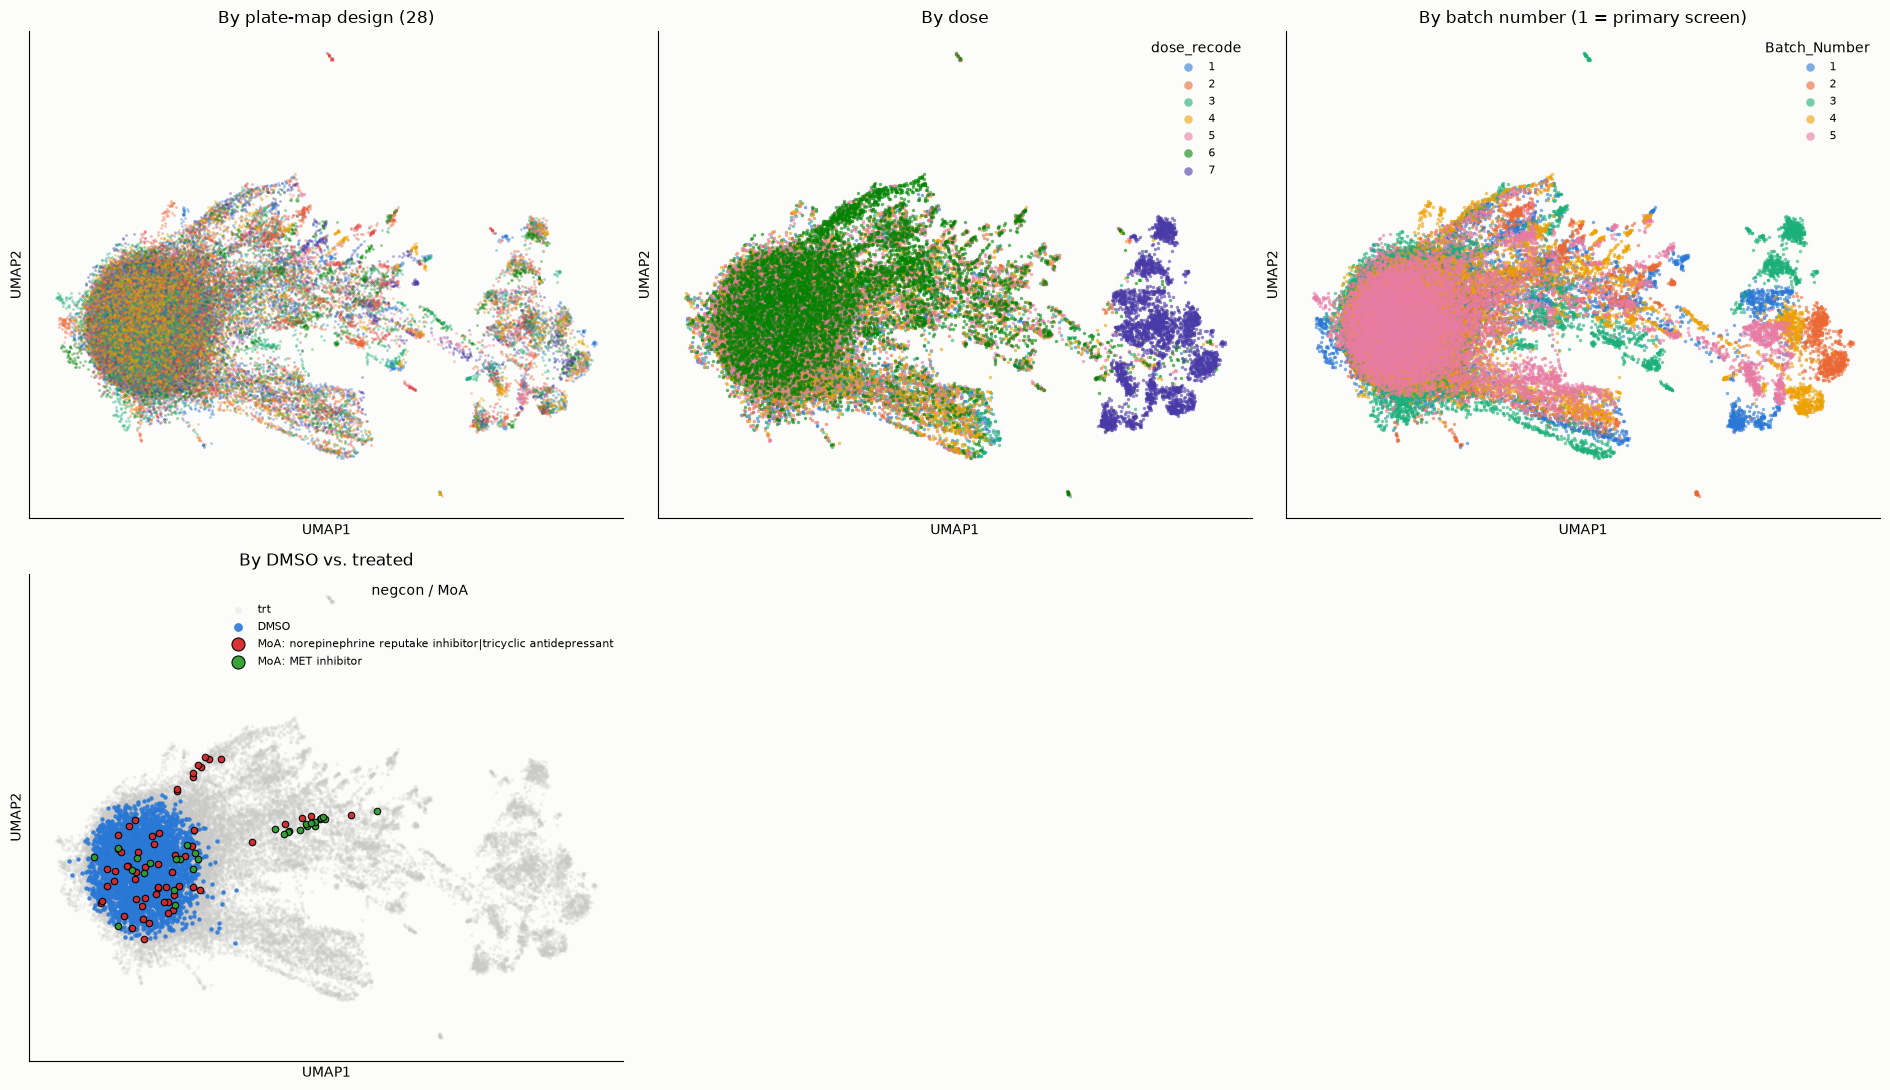

In [7]:
combined_umap = compute_umap(level4c_batch1, morph_feature_cols)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
plot_categorical_umap(axes[0, 0], combined_umap, "Metadata_Plate_Map_Name", "By plate-map design (28)", s=4, alpha=0.4)
plot_categorical_umap(axes[0, 1], combined_umap, "Metadata_dose_recode", "By dose")
plot_categorical_umap(axes[0, 2], combined_umap, "Metadata_Batch_Number", "By batch number (1 = primary screen)")
plot_negcon_umap(axes[1, 0], combined_umap, "By DMSO vs. treated")
axes[1, 1].axis("off")
axes[1, 2].axis("off")
fig.tight_layout()
plt.show()


### 5b. DMSO-only UMAP (batch-correction QC)

If TVN worked, DMSO wells from different batches and plates should
intermix rather than forming batch-colored islands. This is the primary
normalization success criterion for this notebook.


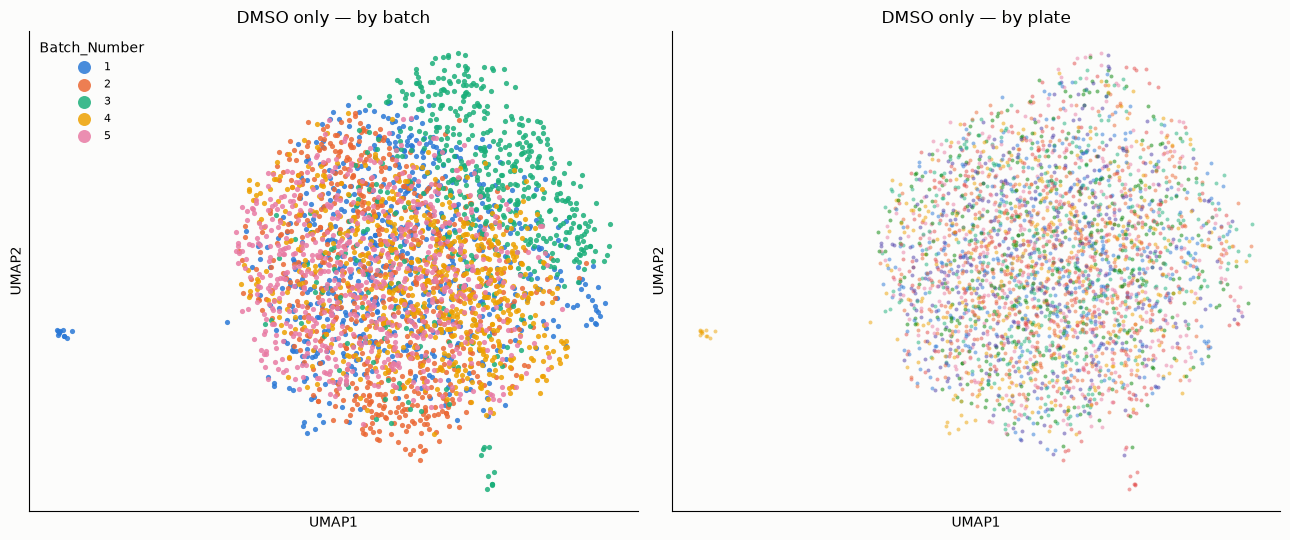

Silhouette by Metadata_Batch_Number (DMSO wells only): -0.022


In [ ]:
dmso_df = level4c_batch1[level4c_batch1["Metadata_broad_sample"] == "DMSO"].reset_index(drop=True)
dmso_umap = compute_umap(dmso_df, morph_feature_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_categorical_umap(axes[0], dmso_umap, "Metadata_Batch_Number", "DMSO only — by batch", s=14, alpha=0.85)
plot_categorical_umap(axes[1], dmso_umap, "Metadata_Plate", "DMSO only — by plate", s=8, alpha=0.5)
fig.tight_layout()
plt.savefig("../figures/lincs_dmso_tvn_umap.png", dpi=150, bbox_inches="tight")
plt.show()

dmso_pca = dmso_umap.obsm["X_pca"]
dmso_batch_labels = dmso_umap.obs["Metadata_Batch_Number"].to_numpy()
dmso_batch_sil = silhouette_score(dmso_pca, dmso_batch_labels)
print(f"Silhouette by Metadata_Batch_Number (DMSO wells only): {dmso_batch_sil:.3f}")


## 6. Silhouette scores

Silhouette on the combined PCA embedding. For **batch correction**, the
metric that matters is `Metadata_Batch_Number` on **DMSO wells only**
(printed in §5b) — values near 0 mean controls from different batches
intermix. The labels below are secondary checks on the full embedding.


In [11]:
pca_combined = combined_umap.obsm["X_pca"]
plate_map_labels = combined_umap.obs["Metadata_Plate_Map_Name"].to_numpy()
dose_labels = combined_umap.obs["Metadata_dose_recode"].to_numpy()
negcon_labels = combined_umap.obs["Metadata_negcon"].to_numpy()
batch_labels = combined_umap.obs["Metadata_Batch_Number"].to_numpy()

rng = np.random.RandomState(RANDOM_STATE)
n = pca_combined.shape[0]
sample_idx = rng.choice(n, size=min(n, 8000), replace=False)

plate_map_sil = silhouette_score(pca_combined[sample_idx], plate_map_labels[sample_idx])
dose_sil = silhouette_score(pca_combined[sample_idx], dose_labels[sample_idx])
negcon_sil = silhouette_score(pca_combined[sample_idx], negcon_labels[sample_idx])
batch_sil = silhouette_score(pca_combined[sample_idx], batch_labels[sample_idx])

print("Full embedding (subsampled):")
print(f"  Silhouette by Metadata_Plate_Map_Name : {plate_map_sil:.3f}")
print(f"  Silhouette by Metadata_dose_recode     : {dose_sil:.3f}")
print(f"  Silhouette by Metadata_negcon          : {negcon_sil:.3f}")
print(f"  Silhouette by Metadata_Batch_Number    : {batch_sil:.3f}")
print(f"DMSO-only batch silhouette (from §5b)    : {dmso_batch_sil:.3f}")


Full embedding (subsampled):
  Silhouette by Metadata_Plate_Map_Name : -0.198
  Silhouette by Metadata_dose_recode     : -0.222
  Silhouette by Metadata_negcon          : -0.590
  Silhouette by Metadata_Batch_Number    : -0.094
DMSO-only batch silhouette (from §5b)    : -0.022


## 7. Does the primary screen (batch 1) reproduce in its confirmatory retest?

Batch 1 measures every plate-map design once; batches 2-5 each retest a
disjoint subset of ~7 designs at 3-4 replicate plates. For every
(`Metadata_broad_sample`, `Metadata_dose_recode`) combination that has
*both* a batch-1 well and at least one batch-2-5 well, correlate batch 1's
single measurement against the mean of its later replicate(s) - the direct,
apples-to-apples technical-reproducibility check this design supports, in
place of HepG2's site-vs-site comparison.


In [12]:
non_dmso = level4c_batch1[level4c_batch1["Metadata_broad_sample"] != "DMSO"]

batch1_wells = non_dmso[non_dmso["Metadata_Batch_Number"] == 1].set_index(["Metadata_broad_sample", "Metadata_dose_recode"])
later_wells = non_dmso[non_dmso["Metadata_Batch_Number"] != 1]
later_mean = later_wells.groupby(["Metadata_broad_sample", "Metadata_dose_recode"])[morph_feature_cols].mean()

shared_idx = batch1_wells.index.intersection(later_mean.index)
print(f"{len(shared_idx)} compound-dose combinations have both a batch-1 well and a later-batch replicate mean")

b1 = batch1_wells.loc[shared_idx, morph_feature_cols].to_numpy(dtype=np.float64)
later = later_mean.loc[shared_idx, morph_feature_cols].to_numpy(dtype=np.float64)
pair_corrs = np.array([np.corrcoef(b1[i], later[i])[0, 1] for i in range(len(shared_idx))])

print(f"batch1-vs-later-batches correlation: mean r={np.nanmean(pair_corrs):.3f}, "
      f"median r={np.nanmedian(pair_corrs):.3f} (n={len(pair_corrs)} compound-dose combinations)")


9393 compound-dose combinations have both a batch-1 well and a later-batch replicate mean
batch1-vs-later-batches correlation: mean r=0.020, median r=0.013 (n=9393 compound-dose combinations)


## 8. Does literature MoA structure survive?

Restricted to the top 8 MoA classes by well count (taking just the first
`|`-separated MoA label per compound, as elsewhere in this project), colored
on the same combined embedding, plus its silhouette score - the well-level
counterpart of the compound-level `moa-fine` silhouette checks in the two
integration notebooks, but here on the full batch1 library rather than only
the compounds shared with expression data.


Silhouette by top-8 Metadata_moa (DMSO/other-MoA wells excluded): -0.407


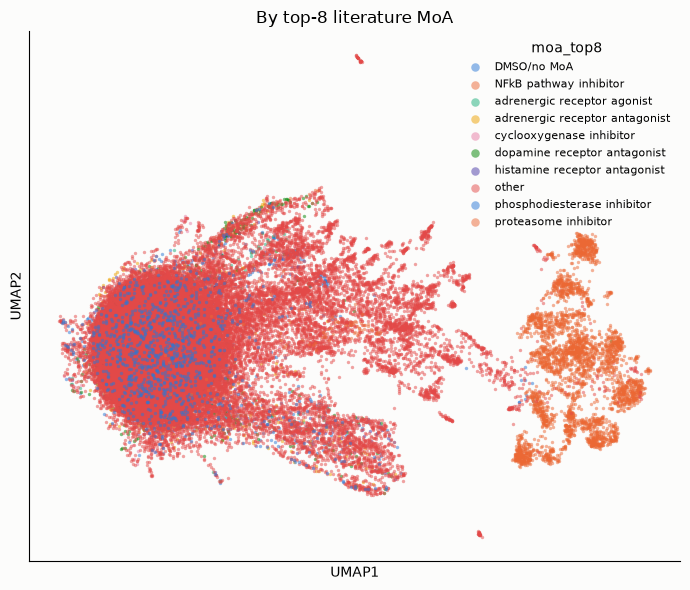

In [13]:
moa_first = level4c_batch1["Metadata_moa"].dropna().str.split("|").str[0]
top_moa = moa_first.value_counts().head(8).index
moa_label = moa_first.where(moa_first.isin(top_moa), "other").reindex(level4c_batch1.index)
moa_label = moa_label.fillna("DMSO/no MoA")
combined_umap.obs["Metadata_moa_top8"] = moa_label.astype(str).to_numpy()

moa_mask = combined_umap.obs["Metadata_moa_top8"] != "DMSO/no MoA"
moa_sil = silhouette_score(pca_combined[moa_mask.to_numpy()], combined_umap.obs.loc[moa_mask, "Metadata_moa_top8"])
print(f"Silhouette by top-8 Metadata_moa (DMSO/other-MoA wells excluded): {moa_sil:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
plot_categorical_umap(ax, combined_umap, "Metadata_moa_top8", "By top-8 literature MoA", s=6, alpha=0.5)
fig.tight_layout()
plt.show()


## 9. Summary

Re-run all cells above and fill in the numbers printed by §5b, §6, §7, and §8.

**Pipeline**: Level 4a (per-plate DMSO `mad_robustize`) → Level 4b (pooled
feature selection) → Level 4c (global TVN / ZCA-cor fit on all DMSO wells).

**Normalization success criterion**: DMSO wells from different batches should
intermix in the §5b UMAP; DMSO-only batch silhouette should be near 0. This
is deliberately *not* the same as the integration notebook's `samples="all"`
Level 4a — that path is validated against Broad but does not correct
cross-plate control scatter.

**Full-embedding silhouettes** (§6): technical labels (`Batch_Number`,
`negcon`) near 0; `Plate_Map_Name` negative is expected (each design spans
~58 compounds). Dose/MoA near 0 at well level is expected for this sparse
screen.

**Reproducibility** (§7) and **MoA** (§8): same interpretation as before,
now computed on Level 4c features.


In [14]:
print("See section 9's markdown for the narrative summary of the numbers computed above.")


See section 9's markdown for the narrative summary of the numbers computed above.
